# Project (Assignment 3): Unsupervised Learning (E-Commerce Orders)

This notebook is your working template for **Assignment 3**.

**Note:** This assessment comprises two parts: question-guided processing/modeling (Unsupervised learning) and free-form exploration.

**Total Marks: 20**

You will:
- Continue working with the expanded dataset from Assignment 1
- Perform **clustering** to identify similar order types
- Apply **market basket analysis** (association rule mining)
- Write up findings throughout the notebook
- Publish your analysis as a github.io page

Work **top-to-bottom**. Complete each task in order before moving on.

## Setup

Run the cell below to import the required Python packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')


ModuleNotFoundError: No module named 'mlxtend'

## Load Your Cleaned Dataset from Assignment 1

Load the cleaned and expanded dataset you created in Assignment 1 (and potentially modified in Assignment 2).

In [ ]:
# ANSWER: Load your cleaned dataset
df = pd.read_csv('data/ecommerce_orders_cleaned.csv')


---
## Task: Unsupervised Learning

### Objective

In this task, you will work on unsupervised learning and support your analysis with visualization. Perform clustering to identify **similar orders** and generate **order type recommendations** based on their characteristics. An order type cluster represents a group of orders with similar purchasing patterns, value structures, and composition.

### 1: Data Preprocessing for Unsupervised Learning [1 Mark]

Goal: Create DataFrames that contain one row per order with features suitable for both clustering and association mining.

#### 1.1 Create `all_orders_df` (one row per order)

Create a new DataFrame called `all_orders_df` with the following columns:

Identifier:
- `order_id` — Unique identifier of the order
- `basket_size` — Monetary value of the order (from `order_total_value`)
- `basket_qty` — Number of items in the order (from `num_items`)
- `freight_ratio` — Proportion of the order value that is freight (computed as `total_freight_value / order_total_value`)
- `product_diversity` — How varied the basket is in terms of product types (computed as `num_unique_products / num_items`)
- `top_product_category` — The dominant product category in the order
- `payment_type` — The payment method used
- `order_size_category` — The order size category (Small/Medium/Large)

Notes:
- `all_orders_df` must have exactly one row per `order_id`.
- No missing values should remain in these columns after preprocessing (apply reasonable handling if needed).
- Handle potential division issues appropriately (e.g., orders with zero values).
- Display the first 10 rows of `all_orders_df`, its shape, and data types.


In [ ]:
# 1.1 ANSWER: Create all_orders_df

# Initialize and extract the base column
all_orders_df = pd.DataFrame()
all_orders_df['order_id'] = df['order_id']
all_orders_df['basket_size'] = df['order_total_value']
all_orders_df['basket_qty'] = df['num_items']

# calculate proportional characteristics
all_orders_df['freight_ratio'] = np.where(
    df['order_total_value'] == 0,
    0,
    df['total_freight_value'] / df['order_total_value']
)

all_orders_df['product_diversity'] = np.where(
    df['num_items'] == 0,
    0,
    df['num_unique_products'] / df['num_items']
)

# Extracting classification features
all_orders_df['top_product_category'] = df['top_product_category']
all_orders_df['payment_type'] = df['payment_type']
all_orders_df['order_size_category'] = df['order_size_category']

# Remove duplicates
all_orders_df = all_orders_df.drop_duplicates(subset=['order_id']).copy()

# No missing values should remain
fill_values = {
    'basket_size': 0,
    'basket_qty': 0,
    'freight_ratio': 0,
    'product_diversity': 0,
    'top_product_category': 'Unknown',
    'payment_type': 'Unknown',
    'order_size_category': 'Unknown'
}
all_orders_df = all_orders_df.fillna(value=fill_values)

# Display first 10 rows
print("========== First 10 Rows ==========")
display(all_orders_df.head(10))

print("\n========== DataFrame Shape ==========")
print(all_orders_df.shape)

print("\n========== Data Types ==========")
print(all_orders_df.dtypes)


========== First 10 Rows ==========


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category
0,sdv-id-whzjUX,744.312535,1,0.092421,1.000000,construction_tools_construction,voucher,Small
1,sdv-id-dbopoJ,1556.667902,1,0.009889,1.000000,health_beauty,credit_card,Small
2,sdv-id-FSEOvM,62.060506,1,0.302145,1.000000,luggage_accessories,debit_card,Small
3,sdv-id-bQcBUR,73.873470,1,0.117375,1.000000,computers_accessories,credit_card,Small
4,sdv-id-MPxIXB,361.961537,3,0.095953,1.000000,pet_shop,voucher,Medium
5,sdv-id-ySodbB,867.750230,7,0.204442,0.857143,sports_leisure,voucher,Large
6,sdv-id-wdwBrk,55.965822,2,0.285101,0.500000,toys,points,Small
7,sdv-id-maBYtk,170.295452,3,0.089290,1.000000,computers_accessories,voucher,Medium
8,sdv-id-oodUXj,83.065603,1,0.236471,1.000000,furniture_decor,voucher,Small
9,sdv-id-zroJIL,98.250248,1,0.369709,1.000000,fashion_bags_accessories,points,Small



========== DataFrame Shape ==========
(46287, 8)

========== Data Types ==========
order_id                 object
basket_size             float64
basket_qty                int64
freight_ratio           float64
product_diversity       float64
top_product_category     object
payment_type             object
order_size_category      object
dtype: object


#### 1.2 Create `orders_analysis_df`

- Use `train_test_split` from sklearn to split the data in `all_orders_df`.
- Set `test_size=0.3` (keep 30% of data for analysis) and `random_state=37` for reproducibility.
- Assign the **test set** to the variable `orders_analysis_df`.

Display the shape of `orders_analysis_df` and show its first 10 rows.


In [ ]:
# 1.2 ANSWER: Create orders_analysis_df using train_test_split

orders_train_df, orders_analysis_df = train_test_split(
    all_orders_df,
    test_size=0.3,
    random_state=37
)

print("========== DataFrame Shape ==========")
print(orders_analysis_df.shape)

print("\n========== First 10 Rows ==========")
display(orders_analysis_df.head(10))

========== DataFrame Shape ==========
(13887, 8)

========== First 10 Rows ==========


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category
1882,sdv-id-ISddRn,132.611695,1,0.126285,1.000000,christmas_supplies,voucher,Small
40995,sdv-id-GmlErp,730.510053,6,0.075288,0.666667,furniture_decor,credit_card,Large
40104,sdv-id-BWpket,632.486142,1,0.051262,1.000000,bed_bath_table,credit_card,Small
25808,sdv-id-krmbPT,47.102393,1,0.248932,1.000000,telephony,credit_card,Small
23294,sdv-id-vhfMmG,133.285008,1,0.135860,1.000000,health_beauty,debit_card,Small
7160,sdv-id-kcTYfM,403.696187,2,0.079065,0.500000,auto,credit_card,Small
7180,sdv-id-tFFFCg,211.465148,2,0.162263,1.000000,furniture_decor,voucher,Small
20801,sdv-id-KgDKAA,57.520738,1,0.228879,1.000000,bed_bath_table,credit_card,Small
19879,sdv-id-cfCjEB,576.212699,3,0.056350,0.666667,bed_bath_table,credit_card,Medium
39874,sdv-id-uxRZME,141.772602,2,0.200719,1.000000,fashion_bags_accessories,credit_card,Small


### 2: Determine the Optimal Number of Clusters [3 Marks]

#### 2.1 Run K-Means for Different Cluster Numbers

- Use **only the four numerical features** from `orders_analysis_df` (`basket_size`, `basket_qty`, `freight_ratio`, `product_diversity`) for clustering.
- Run K-means clustering from **k = 3 to 9** clusters.
- Important: First scale the numerical features using `StandardScaler` before fitting K-means.
- In each run, calculate the **inertia** of the cluster and store the values for each k (3 to 9) in a list or table.

Inertia is a measure of how tightly packed the clusters are. It is the sum of squared distances between each point and its assigned cluster center (centroid). Lower inertia indicates that the clusters are more compact, and the points are closer to their centroids, suggesting better clustering.


In [ ]:
# 2.1 ANSWER: Run K-means for k=3 to 9 and calculate inertia

# Extract four numerical features
num_features = ['basket_size', 'basket_qty', 'freight_ratio', 'product_diversity']
X = orders_analysis_df[num_features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run K-Means (from 3 to 9) and record the Inertia.
inertia_values = []
k_range = range(3, 10)

for k in k_range:
    # Instantiate the K-Means model
    kmeans = KMeans(n_clusters=k, random_state=37, n_init='auto')

    # Fit the standardized data
    kmeans.fit(X_scaled)

    # Extract and save the inertia attribute
    inertia_values.append(kmeans.inertia_)


inertia_table = pd.DataFrame({
    'Number of Clusters (k)': k_range,
    'Inertia': inertia_values
})

print("========== Inertia for Different k ==========")
display(inertia_table)


========== Inertia for Different k ==========


,Number of Clusters (k),Inertia
0,3,28884.287460
1,4,21464.490872
2,5,17303.164622
3,6,15014.005307
4,7,13530.944387
5,8,11762.816173
6,9,10585.957147


#### 2.2 Elbow Method for Optimal Clusters

- Plot the **inertia** (y-axis) against the **number of clusters** (x-axis) to identify the optimal number of clusters using the **Elbow method**.

The Elbow Method helps in selecting the number of clusters by identifying where the inertia starts to decrease more slowly.

- Based on the Elbow plot, **choose the optimal number of clusters** and state your choice clearly.

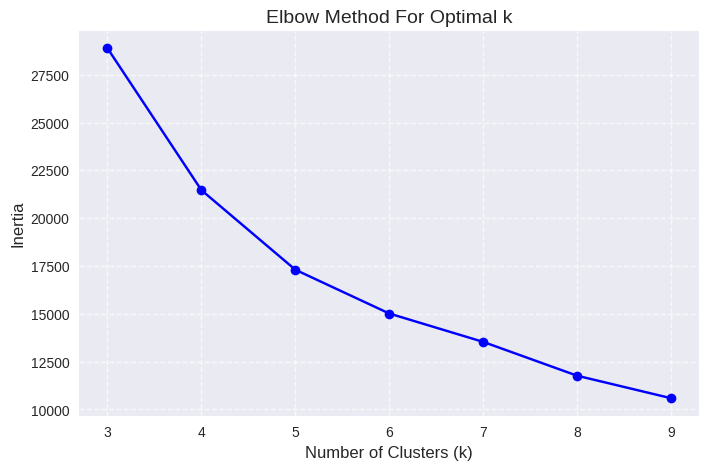

In [ ]:
# 2.2 ANSWER: Create Elbow plot

plt.figure(figsize=(8, 5))

# Drawing a line chart
plt.plot(
    inertia_table['Number of Clusters (k)'],
    inertia_table['Inertia'],
    marker='o',
    linestyle='-',
    color='b'
)

# Add chart title and axis labels
plt.title('Elbow Method For Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)

plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


**Statement of my choice**

I choose 6 as the optimal number of clusters. From the elbow plot, inertia decreases sharply between k=3 and k=6. After k=6, the curve flattens, and inertia reduction becomes small and linear. This shows k=6 is the elbow point: adding more clusters beyond 6 does not significantly improve data partitioning.

### 3: Cluster Analysis and Visualization [3 Marks]

#### 3.1 Identify the Cluster Number for Each Order

- Create a K-means model using the four numerical features from `all_orders_df` and the optimal number of clusters identified in Task 2.
- Fit the model on the scaled numerical features.
- Use the fitted model to assign a cluster number to each order and add a new column called `cluster` to `all_orders_df`.
- Show the first 10 rows of `all_orders_df` to verify cluster assignment.


In [ ]:
# 3.1 ANSWER: Fit K-means with optimal k and assign clusters

optimal_k = 6

# Extract numerical features from the full dataset
num_features = ['basket_size', 'basket_qty', 'freight_ratio', 'product_diversity']
X_all = all_orders_df[num_features]

# Standardize the entire dataset
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# Initialize and train the final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=37, n_init='auto')
kmeans_final.fit(X_all_scaled)

# Add the cluster labels to the original dataframe as a new column
all_orders_df['cluster'] = kmeans_final.labels_

# Display first 10 rows
print(f"========== First 10 Rows with Cluster Assignment (k={optimal_k}) ==========")
display(all_orders_df.head(10))



========== First 10 Rows with Cluster Assignment (k=6) ==========


,order_id,basket_size,basket_qty,freight_ratio,product_diversity,top_product_category,payment_type,order_size_category,cluster
0,sdv-id-whzjUX,744.312535,1,0.092421,1.000000,construction_tools_construction,voucher,Small,0
1,sdv-id-dbopoJ,1556.667902,1,0.009889,1.000000,health_beauty,credit_card,Small,4
2,sdv-id-FSEOvM,62.060506,1,0.302145,1.000000,luggage_accessories,debit_card,Small,1
3,sdv-id-bQcBUR,73.873470,1,0.117375,1.000000,computers_accessories,credit_card,Small,0
4,sdv-id-MPxIXB,361.961537,3,0.095953,1.000000,pet_shop,voucher,Medium,0
5,sdv-id-ySodbB,867.750230,7,0.204442,0.857143,sports_leisure,voucher,Large,5
6,sdv-id-wdwBrk,55.965822,2,0.285101,0.500000,toys,points,Small,2
7,sdv-id-maBYtk,170.295452,3,0.089290,1.000000,computers_accessories,voucher,Medium,0
8,sdv-id-oodUXj,83.065603,1,0.236471,1.000000,furniture_decor,voucher,Small,3
9,sdv-id-zroJIL,98.250248,1,0.369709,1.000000,fashion_bags_accessories,points,Small,1


#### 3.2 Visualize the Clusters

Create two visualizations to understand your clusters:

- **Visualization 1: Cluster Profile Heatmap**
  - Visualize the cluster profiles using a heatmap to understand the average characteristics of each segment.
  - Step 1: Compute the mean of the four numerical features (`basket_size`, `basket_qty`, `freight_ratio`, `product_diversity`) for each cluster.
  - Step 2: Scale these means (e.g., using `StandardScaler` to calculate Z-scores) so that different units (price vs. count) can be compared directly.
  - Step 3: Plot the scaled means as a heatmap:
    - X-axis: Cluster number
    - Y-axis: Feature name
    - Color: Use a diverging colormap (e.g., `RdBu_r`) to distinguish features that are above average (positive Z-score) from those that are below average (negative Z-score)
    - Annotation: Display the Z-score values in each cell
  - Add a clear title.

- **Visualization 2: Cluster Size Distribution**
  - Create a bar chart showing the number of orders in each cluster.
    - X-axis: Cluster number (0, 1, 2, ...)
    - Y-axis: Count of orders
    - This helps you understand if clusters are balanced or if some clusters dominate.
  - Add a title and axis labels.


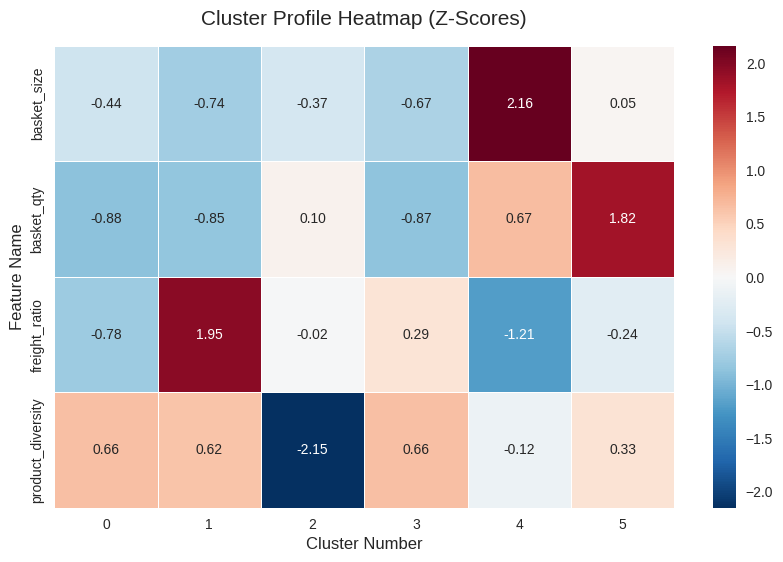

In [ ]:
# 3.2 ANSWER: Visualization 1 - Cluster profile heatmap
# Compute the mean of the four numerical features for each cluster
num_features = ['basket_size', 'basket_qty', 'freight_ratio', 'product_diversity']
cluster_means = all_orders_df.groupby('cluster')[num_features].mean()

# Scale these means using StandardScaler to calculate Z-scores
scaler_heatmap = StandardScaler()
scaled_means_array = scaler_heatmap.fit_transform(cluster_means)

scaled_means_df = pd.DataFrame(
    scaled_means_array,
    columns=cluster_means.columns,
    index=cluster_means.index
).T

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    scaled_means_df,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=.5
)
plt.title('Cluster Profile Heatmap (Z-Scores)', fontsize=15, pad=15)
plt.xlabel('Cluster Number', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.show()



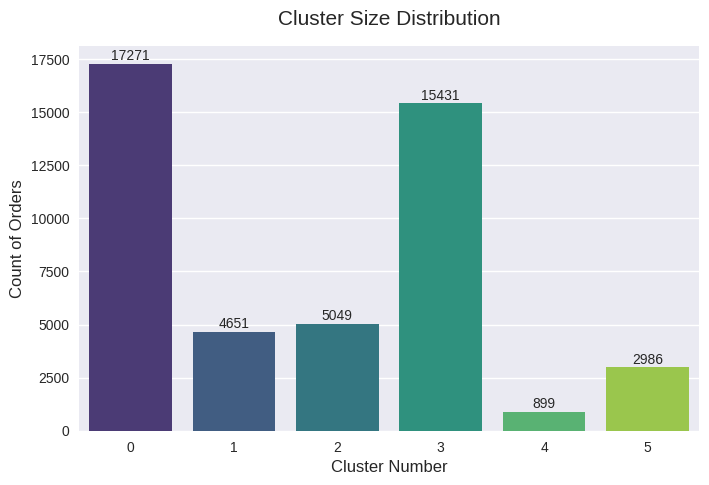

In [ ]:
# 3.2 ANSWER: Visualization 2 - Cluster size distribution
# Calculate the number of orders for each cluster
cluster_counts = all_orders_df['cluster'].value_counts().sort_index()

# Draw a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette="viridis"
)
plt.title('Cluster Size Distribution', fontsize=15, pad=15)
plt.xlabel('Cluster Number', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)

for i, count in enumerate(cluster_counts.values):
    plt.text(i, count + (max(cluster_counts.values)*0.01), str(count), ha='center', fontsize=10)

plt.show()



**Briefly comment (2-3 sentences) on:**

- How well separated do the clusters appear based on the heatmap?
- Which features seem to have the most significant impact on defining the clusters? Why might this be the case?
- Based on the visualizations that you have generated, comment on the nature of the clusters and what it implies for an e-commerce business



**3.2 ANSWER:**

- The clusters appear well-separated, as each segment is distinctly defined by extreme positive or negative Z-scores in at least one key feature.

- Features like basket_size, freight_ratio, and product_diversity have the most significant impact, as they strongly capture contrasting purchasing behaviors such as premium spending versus bulk buying.

- For an e-commerce business, this implies operations should be optimized for dominant low-value orders, while tailored strategies are needed to maximize profitability from high-value niche segments.


### 4: Market Basket Analysis (Association Rule Mining) [8 Marks]

#### 4.1 Context: What is Market Basket Analysis?

Market Basket Analysis is an unsupervised learning technique that identifies which products, categories, or attributes are frequently observed together. In e-commerce, this helps answer questions such as:

- "Which payment methods are preferred for which product categories?"
- "Do certain order sizes correlate with specific product types?"
- "What are the multi-dimensional patterns across category, payment, and order size?"

Association rules are commonly described using three key metrics:

- **Support**: How frequently a pattern occurs (0-1 scale)
- **Confidence**: Likelihood of the consequent given the antecedent (0-1 scale)
- **Lift**: How much more likely the rule is compared to random chance (> 1 indicates a positive association)

The Apriori algorithm discovers frequent itemsets and then generates association rules from them.

In this task, you will perform Market Basket Analysis using the categorical features from `all_orders_df` to discover multi-dimensional associations between product category, payment type, and order size category.


#### 4.2 Prepare Transaction Data [1 Mark]

Convert each order in `all_orders_df` into a simple "basket" representation.

Create a Python list called `transactions`, where each element represents one order and contains exactly three string items constructed from that order:

- `cat_{top_product_category}` (e.g., `cat_electronics`, `cat_furniture_decor`)
- `pay_{payment_type}` (e.g., `pay_credit_card`, `pay_boleto`)
- `size_{order_size_category}` (e.g., `size_Small`, `size_Large`)

After constructing `transactions`, display the first 5 transactions to verify the format.


In [ ]:
# 4.2 ANSWER: Create transaction list

# pack three columns of data and generate a list of strings with a specific prefix
transactions = [
    [f"cat_{cat}", f"pay_{pay}", f"size_{size}"]
    for cat, pay, size in zip(
        all_orders_df['top_product_category'],
        all_orders_df['payment_type'],
        all_orders_df['order_size_category']
    )
]

# Display the first 5 transactions to verify the format
print("========== First 5 Transactions ==========")
for i in range(5):
    print(transactions[i])

========== First 5 Transactions ==========
['cat_construction_tools_construction', 'pay_voucher', 'size_Small']
['cat_health_beauty', 'pay_credit_card', 'size_Small']
['cat_luggage_accessories', 'pay_debit_card', 'size_Small']
['cat_computers_accessories', 'pay_credit_card', 'size_Small']
['cat_pet_shop', 'pay_voucher', 'size_Medium']


#### 4.3 Encode Transactions and Apply Apriori Algorithm [2 Marks]

Use the `mlxtend` library to discover frequent itemsets and generate association rules.

- Step 1: Encode transactions using `TransactionEncoder` and display the shape of the encoded DataFrame.
- Step 2: Apply `apriori()` with `min_support = 0.01` and `use_colnames = True`, then display the number of frequent itemsets found.
- Step 3: Generate association rules using `association_rules()` with `metric = 'lift'` and `min_threshold = 1.0`, then display the number of rules generated.


In [ ]:
# 4.3 ANSWER: Step 1 - Encode transactions
# Instantiate encoder
encoder = TransactionEncoder()

# Fit and transform the transactions list
encoded_array = encoder.fit(transactions).transform(transactions)

# Convert the transformed boolean array back into DataFrame
encoded_df = pd.DataFrame(encoded_array, columns=encoder.columns_)

# Print shape
print("========== Encoded DataFrame Shape ==========")
print(encoded_df.shape)


========== Encoded DataFrame Shape ==========
(46287, 79)


In [ ]:
# 4.3 ANSWER: Step 2 - Apply Apriori
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)

print("========== Number of Frequent Itemsets Found ==========")
print(len(frequent_itemsets))


========== Number of Frequent Itemsets Found ==========
102


In [ ]:
# 4.3 ANSWER: Step 3 - Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

print("========== Number of Association Rules Generated ==========")
print(len(rules))


========== Number of Association Rules Generated ==========
138


#### 4.4 Extract and Display Top 10 Rules [1 Mark]

Sort the association rules by **lift** in descending order and display the top 10 rules in a table showing:

- Antecedents (left-hand side of rule)
- Consequents (right-hand side of rule)
- Support
- Confidence
- Lift

Example rule output and interpretation:

| antecedents | consequents | support | confidence | lift |
| :--- | :--- | :--- | :--- | :--- |
| (cat_furniture_decor, size_Large) | (pay_credit_card) | 0.042 | 0.756 | 1.84 |

"Customers who purchase **furniture** in **large orders** have a **75.6% probability** (confidence) of paying with a **credit card**. This behavior is **1.84 times more likely** (lift) than the general probability of using a credit card.


In [ ]:
# 4.4 ANSWER: Display top 10 rules by lift

# Sort by lift in descending order and take the top 10 rows
top_10_rules = rules.sort_values(by='lift', ascending=False).head(10)

# Only extract the 5 columns required by the question
columns_to_display = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
top_10_rules_display = top_10_rules[columns_to_display]

# Print Display
print("========== Top 10 Association Rules by Lift ==========")
display(top_10_rules_display)

========== Top 10 Association Rules by Lift ==========


,antecedents,consequents,support,confidence,lift
24,(size_Large),(cat_furniture_decor),0.014583,0.392899,5.328480
25,(cat_furniture_decor),(size_Large),0.014583,0.197773,5.328480
77,(cat_bed_bath_table),"(pay_credit_card, size_Medium)",0.016851,0.121514,2.023212
72,"(pay_credit_card, size_Medium)",(cat_bed_bath_table),0.016851,0.280576,2.023212
76,(size_Medium),"(pay_credit_card, cat_bed_bath_table)",0.016851,0.171693,1.757439
73,"(pay_credit_card, cat_bed_bath_table)",(size_Medium),0.016851,0.172490,1.757439
26,(cat_furniture_decor),(size_Medium),0.012660,0.171696,1.749354
27,(size_Medium),(cat_furniture_decor),0.012660,0.128990,1.749354
9,(cat_bed_bath_table),(size_Medium),0.022749,0.164044,1.671388
8,(size_Medium),(cat_bed_bath_table),0.022749,0.231785,1.671388


#### 4.5 Interpretation (3-4 sentences) [3 Marks]

Write a brief interpretation explaining:

- What the top 3 unique rules tell you about customer behavior
- Which combinations are most strongly associated (highest lift)
- Why these associations might exist (business intuition)
- Change the min_support value to 0.005 and 0.3 and comment on any changes in the rules identified


**4.5 ANSWER:**

*The top rules show that furniture_decor is most strongly associated with size_Large orders (highest lift of 5.3), which makes sense because furniture items are naturally bulky and expensive. Another key behavior is that customers buying bed_bath_table items usually place size_Medium orders and prefer paying with a credit_card (lift > 2.0). If we decrease min_support to 0.005, we will get many more rules by including rarer purchases, but if we increase it to 0.3, we will likely find zero rules because it is too strict for any combination to appear in 30% of all orders.*


#### 4.6 Business Recommendations (2-3 bullet points) [1 Mark]

Based on the discovered associations, provide actionable business recommendations for an e-commerce firm.


**4.6 ANSWER:**

*[Write your business recommendations here as bullet points]*

- Optimize Shipping for Furniture: Since furniture purchases are very strongly associated with large orders (lift > 5.0), the company should negotiate better rates with heavy-freight shipping partners to reduce costs and improve profit margins.

- Credit Card Promotions for Home Goods: There is a strong link (lift > 2.0) between bed_bath_table items and credit card payments. The business can partner with credit card companies to offer discounts or cashback for the home goods category to encourage more sales.

- Bundle Recommendations: Knowing that large orders are often furniture, the platform can automatically recommend complementary small items (like pillows or lamps) during checkout to increase the overall basket size.


#### Tips

- Rules with **lift > 1.5** are considered strong associations; rules with **lift > 2.0** are very strong.
- When writing interpretations, explain not just the statistical strength but also the **business logic** behind the patterns.

---
## Task: Report (5 Marks)

### Objective

(Note: No separate report submission is required.) The report comprises the write-up that you have been working on within this iPython notebook. The write-up/report should clearly describe the steps performed and the reasoning behind each processing done for all the tasks from Assignment 1 until Association mining above.

### 1: Write-up / Report

Describe the steps performed and the reasoning behind each processing step for all tasks you have worked on so far:

- Assignment 1 (data cleaning and preprocessing)
- Assignment 2 (supervised learning)
- Assignment 3 (unsupervised learning)

Include your explanations inline near the cells where processing is done, and keep your descriptions concise but clear. Connect each analysis step to business objectives where appropriate.


---
### 2: Publish the Report

Publish the report as a read-only github.io static page.

- Note: this differs from setting up a GitHub repository with your iPython notebook in it.
- Convert your notebook to HTML and host it on GitHub Pages (e.g., using nbconvert or Jupyter Book).

Ensure the page is publicly accessible and provide the URL in your Canvas submission.

**Your published URL:**

*[Add your github.io URL here once published]*


---
# End of Assignment 3

**Before submission, ensure:**
1. All code cells execute without errors
2. All markdown cells contain your written explanations
3. Visualizations are clear and properly labeled
4. Your notebook tells a coherent story from start to finish
5. Your github.io page is published and URL is provided

**Good luck!**